# Generate Synthetic Severity Labels for Training

Creates severity scores (1-10) based on issue type and random variation.
Uses existing classification model predictions as features.

## Imports

In [1]:
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple
from collections import Counter

## Configuration

Define base severity scores by issue type and ML class mappings.

In [2]:
# Base severity by issue type
BASE_SEVERITY = {
    "DAMAGED_ELECTRICAL": 9,  # Safety hazard
    "FALLEN_TREE": 8,         # Road blockage, safety
    "DEAD_ANIMAL": 7,         # Health hazard
    "POTHOLE": 6,             # Vehicle damage, accidents
    "DAMAGED_CONCRETE": 6,    # Structural safety
    "DAMAGED_SIGN": 5,        # Navigation safety
    "GARBAGE": 4,             # Health, aesthetics
    "ILLEGAL_PARKING": 3,     # Traffic flow
    "VANDALISM": 3,           # Aesthetics, property
}

# ML class names to issue types
ML_CLASS_TO_TYPE = {
    "Potholes and Road Damage": "POTHOLE",
    "Littering": "GARBAGE",
    "Illegal Parking Issues": "ILLEGAL_PARKING",
    "Broken Road Sign Issues": "DAMAGED_SIGN",
    "Fallen trees": "FALLEN_TREE",
    "Vandalism Issues": "VANDALISM",
    "Dead Animal Pollution": "DEAD_ANIMAL",
    "Damaged concrete structures": "DAMAGED_CONCRETE",
    "Damaged Electric wires and poles": "DAMAGED_ELECTRICAL",
}

print("Issue types configured:")
for issue_type, severity in sorted(BASE_SEVERITY.items(), key=lambda x: -x[1]):
    print(f"  {issue_type}: Base severity = {severity}")

Issue types configured:
  DAMAGED_ELECTRICAL: Base severity = 9
  FALLEN_TREE: Base severity = 8
  DEAD_ANIMAL: Base severity = 7
  POTHOLE: Base severity = 6
  DAMAGED_CONCRETE: Base severity = 6
  DAMAGED_SIGN: Base severity = 5
  GARBAGE: Base severity = 4
  ILLEGAL_PARKING: Base severity = 3
  VANDALISM: Base severity = 3


## Severity Label Generation Function

In [3]:
def generate_severity_label(
    issue_type: str,
    confidence: float = 1.0,
    add_noise: bool = True
) -> Tuple[float, str]:
    """
    Generate a severity score for an issue.

    Args:
        issue_type: The type of issue (e.g., POTHOLE, GARBAGE)
        confidence: Classification confidence (0-1)
        add_noise: Whether to add random variation

    Returns:
        Tuple of (severity_score, reasoning)
    """
    base = BASE_SEVERITY.get(issue_type, 5)

    # Add random variation (-1.5 to +1.5)
    if add_noise:
        variation = random.uniform(-1.5, 1.5)
    else:
        variation = 0

    # Adjust for confidence (lower confidence = slightly lower severity)
    confidence_adjustment = (confidence - 0.7) * 2  # Range: -0.6 to +0.6

    # Calculate final score
    score = base + variation + confidence_adjustment
    score = max(1, min(10, score))  # Clamp to 1-10
    score = round(score, 1)

    # Generate reasoning
    severity_factors = []
    if base >= 8:
        severity_factors.append("high safety risk")
    elif base >= 6:
        severity_factors.append("moderate safety concern")
    elif base >= 4:
        severity_factors.append("quality of life impact")
    else:
        severity_factors.append("minor inconvenience")

    if variation > 1:
        severity_factors.append("appears severe from image")
    elif variation < -1:
        severity_factors.append("appears minor from image")

    reasoning = f"{issue_type.replace('_', ' ').title()}: {', '.join(severity_factors)}"

    return score, reasoning

# Test the function
for issue_type in ["DAMAGED_ELECTRICAL", "POTHOLE", "GARBAGE", "VANDALISM"]:
    score, reasoning = generate_severity_label(issue_type, confidence=0.85)
    print(f"{issue_type}: {score} - {reasoning}")

DAMAGED_ELECTRICAL: 9.6 - Damaged Electrical: high safety risk
POTHOLE: 5.6 - Pothole: moderate safety concern
GARBAGE: 4.5 - Garbage: quality of life impact
VANDALISM: 2.5 - Vandalism: minor inconvenience


## Generate Training Dataset

In [4]:
def generate_training_data(num_samples: int = 2000) -> List[Dict]:
    """
    Generate synthetic severity training data.

    Args:
        num_samples: Number of samples to generate

    Returns:
        List of training samples with issue_type, confidence, severity, reasoning
    """
    data = []
    issue_types = list(BASE_SEVERITY.keys())

    for _ in range(num_samples):
        issue_type = random.choice(issue_types)
        confidence = random.uniform(0.5, 1.0)
        severity, reasoning = generate_severity_label(issue_type, confidence)

        data.append({
            "issue_type": issue_type,
            "confidence": round(confidence, 3),
            "severity": severity,
            "reasoning": reasoning,
        })

    return data

print("Generating severity training data...")
random.seed(42)
data = generate_training_data(2000)
print(f"Generated {len(data)} samples")

Generating severity training data...
Generated 2000 samples


## Analyze Data Distribution

In [5]:
# Severity distribution
print("Severity distribution:")
severity_bins = Counter(int(d["severity"]) for d in data)
for severity in sorted(severity_bins.keys()):
    print(f"  {severity}: {severity_bins[severity]}")

print("\nIssue type distribution:")
type_dist = Counter(d["issue_type"] for d in data)
for issue_type, count in type_dist.most_common():
    print(f"  {issue_type}: {count}")

Severity distribution:
  1: 60
  2: 170
  3: 270
  4: 282
  5: 304
  6: 285
  7: 250
  8: 205
  9: 118
  10: 56

Issue type distribution:
  ILLEGAL_PARKING: 236
  DAMAGED_SIGN: 234
  VANDALISM: 232
  DAMAGED_CONCRETE: 232
  FALLEN_TREE: 228
  POTHOLE: 216
  DAMAGED_ELECTRICAL: 216
  DEAD_ANIMAL: 206
  GARBAGE: 200


## Save Training Data

In [6]:
output_dir = Path("../models")
output_dir.mkdir(exist_ok=True)

output_path = output_dir / "severity_training_data.json"
with open(output_path, "w") as f:
    json.dump(data, f, indent=2)

print(f"Saved to: {output_path}")

Saved to: ../models/severity_training_data.json


## Visualize Distributions

/var/folders/68/xfvgc1cj3w74fb3f3s9g1vzh0000gn/T/ipykernel_66838/3319956070.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(box_data, labels=[t.replace('_', '\n') for t in sorted_types])


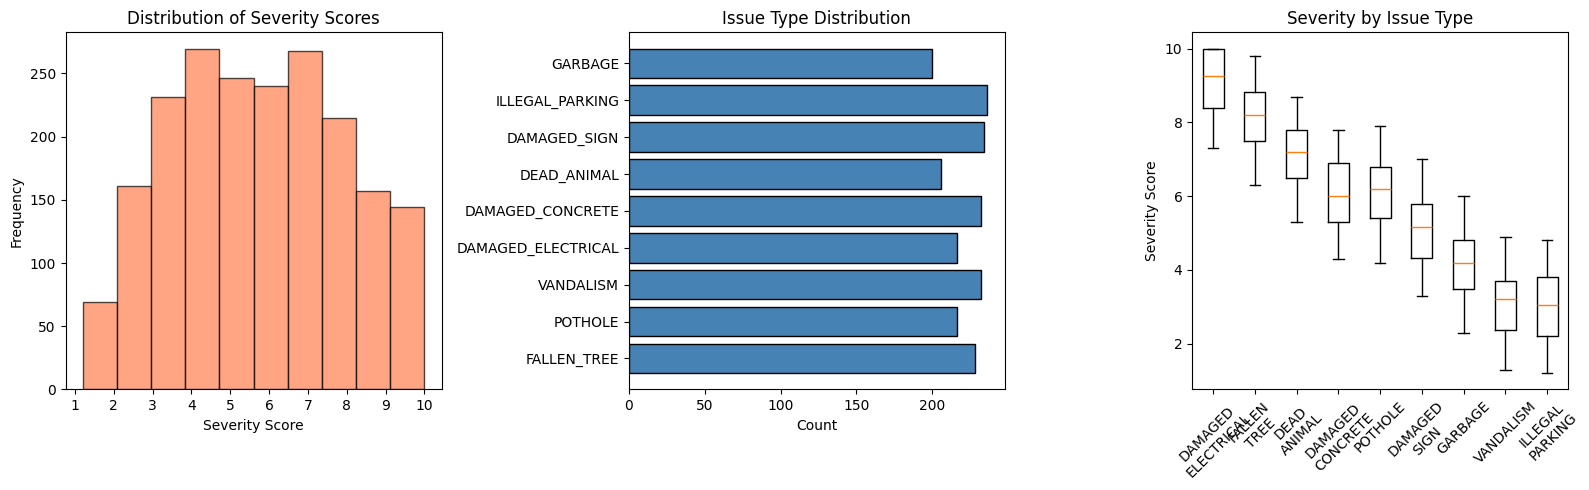

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Severity distribution histogram
severities = [d["severity"] for d in data]
axes[0].hist(severities, bins=10, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Severity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Severity Scores')
axes[0].set_xticks(range(1, 11))

# Issue type distribution
issue_types = list(type_dist.keys())
counts = list(type_dist.values())
axes[1].barh(issue_types, counts, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Count')
axes[1].set_title('Issue Type Distribution')

# Severity by issue type (box plot simulation)
type_severities = {}
for d in data:
    if d["issue_type"] not in type_severities:
        type_severities[d["issue_type"]] = []
    type_severities[d["issue_type"]].append(d["severity"])

sorted_types = sorted(type_severities.keys(), key=lambda x: np.mean(type_severities[x]), reverse=True)
box_data = [type_severities[t] for t in sorted_types]
axes[2].boxplot(box_data, labels=[t.replace('_', '\n') for t in sorted_types])
axes[2].set_ylabel('Severity Score')
axes[2].set_title('Severity by Issue Type')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Sample Data Preview

In [8]:
import pandas as pd

df = pd.DataFrame(data)
print("Sample data preview:")
display(df.head(10))

print("\nSummary statistics:")
display(df.describe())

Sample data preview:


,issue_type,confidence,severity,reasoning
0,FALLEN_TREE,0.513,7.0,Fallen Tree: high safety risk
1,POTHOLE,0.570,4.5,"Pothole: moderate safety concern, appears mino..."
2,VANDALISM,0.543,2.5,Vandalism: minor inconvenience
3,DAMAGED_ELECTRICAL,0.547,7.9,Damaged Electrical: high safety risk
4,DAMAGED_ELECTRICAL,0.781,9.8,Damaged Electrical: high safety risk
5,VANDALISM,0.710,2.9,Vandalism: minor inconvenience
6,DAMAGED_CONCRETE,0.905,4.9,"Damaged Concrete: moderate safety concern, app..."
7,DEAD_ANIMAL,0.849,6.8,Dead Animal: moderate safety concern
8,DEAD_ANIMAL,0.608,7.6,Dead Animal: moderate safety concern
9,FALLEN_TREE,0.546,6.5,"Fallen Tree: high safety risk, appears minor f..."



Summary statistics:


,confidence,severity
count,2000.000000,2000.00000
mean,0.740199,5.72975
std,0.143079,2.20745
min,0.500000,1.20000
25%,0.615000,3.97500
50%,0.734000,5.70000
75%,0.864000,7.40000
max,1.000000,10.00000
